# 01. 데이터 탐색 및 전처리 (EDA)

**작성일**: 2026-09-17

**목표**
- `dataset/ChatbotData.xlsx` (Q, A, label) 구조 확인
- 결측치/중복/길이 분포 등 기초 통계 파악
- 정제(공백 정규화, 중복 제거) 후 train/val/test로 분할하여 이후 노트북(02~)에서 재사용할 수 있도록 저장

**출처**: songys/Chatbot_data (일상다반사 트위터 기반 한국어 챗봇 Q-A 페어, label 0=일상 1=이별(부정) 2=사랑)

In [11]:
# 2026-09-17: 기본 라이브러리 로드 및 데이터 읽기
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import re
from pathlib import Path

# Windows 환경 한글 폰트 설정 (맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

DATA_PATH = Path('../dataset/ChatbotData.xlsx')
df = pd.read_excel(DATA_PATH)
df.head()

,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [12]:
# 2026-09-17: 데이터 기본 정보 확인 (행/열 개수, 타입, 결측치)
print('shape:', df.shape)
df.info()
print('\n결측치 개수')
print(df.isna().sum())

shape: (11823, 3)
<class 'pandas.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Q       11823 non-null  str  
 1   A       11823 non-null  str  
 2   label   11823 non-null  int64
dtypes: int64(1), str(2)
memory usage: 1.1 MB

결측치 개수
Q        0
A        0
label    0
dtype: int64


In [13]:
# 2026-09-17: 완전 중복 행 및 (Q, A) 중복 확인
n_dup_full = df.duplicated().sum()
n_dup_qa = df.duplicated(subset=['Q', 'A']).sum()
n_dup_q = df.duplicated(subset=['Q']).sum()
print(f'전체 컬럼 기준 중복: {n_dup_full}건')
print(f'(Q, A) 기준 중복: {n_dup_qa}건')
print(f'Q만 기준 중복(같은 질문, 다른 답변 포함): {n_dup_q}건')

전체 컬럼 기준 중복: 0건
(Q, A) 기준 중복: 73건
Q만 기준 중복(같은 질문, 다른 답변 포함): 161건


## label(감정) 분포

label
0    5290
1    3570
2    2963
Name: count, dtype: int64


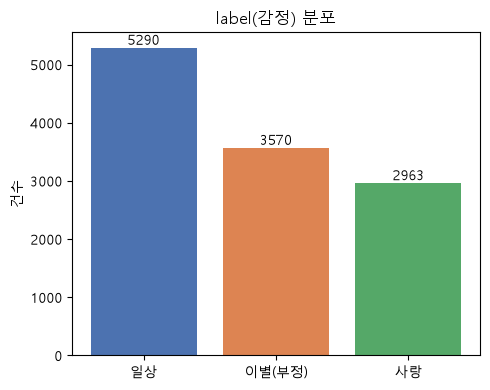

In [14]:
# 2026-09-17: label 분포 확인 (0=일상, 1=이별/부정, 2=사랑)
label_map = {0: '일상', 1: '이별(부정)', 2: '사랑'}
label_counts = df['label'].value_counts().sort_index()
print(label_counts)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar([label_map[i] for i in label_counts.index], label_counts.values, color=['#4C72B0', '#DD8452', '#55A868'])
ax.set_title('label(감정) 분포')
ax.set_ylabel('건수')
for i, v in enumerate(label_counts.values):
    ax.text(i, v + 50, str(v), ha='center')
plt.tight_layout()
plt.savefig('../dataset/processed/label_distribution.png', dpi=120)
plt.show()

## Q/A 길이 분포
어절(공백 split) 기준과 음절(글자) 기준 두 가지로 확인한다.

In [15]:
# 2026-09-17: Q/A 길이(음절 수, 어절 수) 계산
df['Q_char_len'] = df['Q'].str.len() # 음절
df['A_char_len'] = df['A'].str.len()
df['Q_word_len'] = df['Q'].str.split().apply(len) # 어절
df['A_word_len'] = df['A'].str.split().apply(len)

df[['Q_char_len', 'A_char_len', 'Q_word_len', 'A_word_len']].describe()

,Q_char_len,A_char_len,Q_word_len,A_word_len
count,11823.000000,11823.000000,11823.000000,11823.000000
mean,12.879049,15.015140,3.587414,3.693648
std,6.167467,6.701835,1.618897,1.857292
min,1.000000,1.000000,1.000000,1.000000
25%,9.000000,10.000000,2.000000,2.000000
50%,12.000000,14.000000,3.000000,3.000000
75%,16.000000,18.000000,4.000000,5.000000
max,56.000000,76.000000,15.000000,21.000000


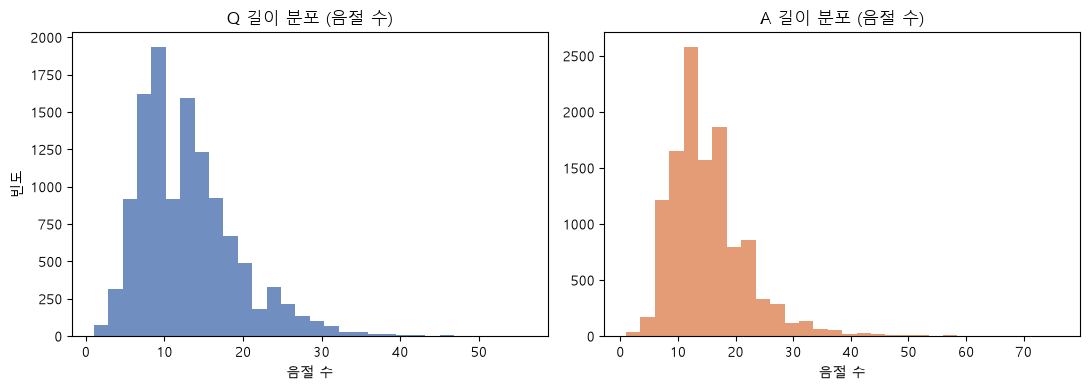

Q 길이 95 percentile: 25.0  / 최댓값: 56
A 길이 95 percentile: 27.0  / 최댓값: 76


In [16]:
# 2026-09-17: 길이 분포 히스토그램 (Q/A, 음절 기준)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(df['Q_char_len'], bins=30, color='#4C72B0', alpha=0.8)
axes[0].set_title('Q 길이 분포 (음절 수)')
axes[0].set_xlabel('음절 수')
axes[0].set_ylabel('빈도')

axes[1].hist(df['A_char_len'], bins=30, color='#DD8452', alpha=0.8)
axes[1].set_title('A 길이 분포 (음절 수)')
axes[1].set_xlabel('음절 수')

plt.tight_layout()
plt.savefig('../dataset/processed/length_distribution.png', dpi=120)
plt.show()

print('Q 길이 95 percentile:', np.percentile(df['Q_char_len'], 95), ' / 최댓값:', df['Q_char_len'].max())
print('A 길이 95 percentile:', np.percentile(df['A_char_len'], 95), ' / 최댓값:', df['A_char_len'].max())

## percentile과 max_length

- **percentile(백분위수) 의미**: 위 출력의 "Q 길이 95 percentile = 25.0"은 *전체 Q 문장 중 95%가 25음절 이하*라는 뜻이다. 반대로 말하면 25음절보다 긴 문장은 전체의 상위 5%뿐이라는 의미이고, 이 값은 위에서 함께 출력한 **최댓값**(이상치 1건)과는 전혀 다른 지표다.
- **왜 최댓값이 아니라 95 percentile을 기준으로 max_length를 정하는가**:
    1. 히스토그램에서 보이듯 문장 길이는 짧은 쪽에 몰려 있고, 극소수의 매우 긴 문장이 긴 꼬리(long tail)를 만든다.
    2. max_length를 **최댓값**으로 잡으면 그 극소수 이상치 때문에 나머지 대부분의 짧은 문장도 전부 그 길이까지 padding되어 학습 시 불필요한 연산량·메모리 낭비가 커진다.
    3. 반대로 max_length를 너무 짧게(예: 평균) 잡으면 긴 문장들이 많이 잘려(truncation) 정보 손실이 커진다.
    4. **95 percentile**은 "이상치 약 5%만 일부 잘리는 것을 감수하고 데이터의 95%는 손실 없이 담는" 절충점이라, 토크나이저 max_length를 정할 때 실무에서 흔히 쓰는 기준이다.
- 이후 02번 노트북부터 토크나이저의 `max_length`는 이 값(Q 95th ≈25, A 95th ≈27)에 약간의 여유를 더한 값(예: 32/64 등)으로 설정할 예정이다.

## 전처리

- 공백 정규화(연속 공백 -> 단일 공백, 앞뒤 공백 제거)
- (Q, A) 완전 중복 제거
- 빈 문자열 행 제거


In [17]:
# 2026-09-18: 텍스트 정제 함수 정의 및 적용 (공백 정규화, 빈 문자열 제거)
def clean_text(text: str) -> str:
    text = str(text).strip()
    text = re.sub(r'\s+', ' ', text)  # 연속 공백 -> 단일 공백
    return text

n_before = len(df)

df_clean = df.copy()
df_clean['Q'] = df_clean['Q'].apply(clean_text)
df_clean['A'] = df_clean['A'].apply(clean_text)

# 빈 문자열 제거
df_clean = df_clean[(df_clean['Q'].str.len() > 0) & (df_clean['A'].str.len() > 0)]
print(f'정제(공백 정규화) 적용, 빈 문자열 제거 후: {len(df_clean)}건')

정제(공백 정규화) 적용, 빈 문자열 제거 후: 11823건


In [18]:
# 2026-09-18: (Q, A) 기준 중복 행을 직접 눈으로 확인
dup_mask = df_clean.duplicated(subset=['Q', 'A'], keep=False)  # 중복 그룹에 속한 모든 행(첫 등장 포함) 표시
dup_rows = df_clean[dup_mask].sort_values(['Q', 'A'])
n_will_remove = df_clean.duplicated(subset=['Q', 'A']).sum()  # 그룹별 첫 행 제외 -> 실제로 제거될 행 수

print(f'(Q, A) 중복 그룹에 속한 행: 총 {len(dup_rows)}행')
print(f'-> 이 중 그룹별 첫 행을 남기고 실제로 제거될 행: {n_will_remove}행')
dup_rows

(Q, A) 중복 그룹에 속한 행: 총 146행
-> 이 중 그룹별 첫 행을 남기고 실제로 제거될 행: 73행


,Q,A,label,Q_char_len,A_char_len,Q_word_len,A_word_len
152,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,0,23,6,7,1
5527,결혼이나 하지 왜 자꾸 나한테 화 내냐구!,힘들겠네요.,1,23,6,7,1
189,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,0,14,23,3,5
5537,고백하고 후회하면 어떡하지,후회는 후회를 낳을뿐이에요. 용기 내세요.,1,14,23,3,5
226,공부는 내 체질이 아닌 것 같아,확신이 없나봐요.,0,17,9,6,2
...,...,...,...,...,...,...,...
8780,회사 사람들이 아직도 불편해,회사에는 동료가 있을 뿐이에요.,1,15,17,4,4
5232,회사에는 왜 친구 같은 사람이 없을까,회사는 친구 사귀는 곳이 아니에요.,0,20,19,6,5
8782,회사에는 왜 친구 같은 사람이 없을까,회사는 친구 사귀는 곳이 아니에요.,1,20,19,6,5
5246,후련하달까,후련하니 다행이에요.,0,5,11,1,2


In [20]:
# 2026-09-18: 위에서 확인한 (Q, A) 완전 중복 행 제거
df_clean = df_clean.drop_duplicates(subset=['Q', 'A']).reset_index(drop=True)

n_after = len(df_clean)
print(f'정제 전: {n_before}건 -> 정제 후: {n_after}건 (제거 {n_before - n_after}건)')

정제 전: 11823건 -> 정제 후: 11750건 (제거 73건)


## train / val / test 분할
label 비율을 유지하도록 stratify하여 8:1:1로 분할한다.

In [21]:
# 2026-09-17: train/val/test 분할 (8:1:1, label stratify)
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_clean, test_size=0.2, random_state=42, stratify=df_clean['label']
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.5, random_state=42, stratify=temp_df['label']
)

print(f'train: {len(train_df)}건, val: {len(val_df)}건, test: {len(test_df)}건')

train: 9400건, val: 1175건, test: 1175건


In [22]:
# 2026-09-17: 분할 결과를 이후 노트북(02~)에서 재사용하기 위해 저장
out_dir = Path('../dataset/processed')
out_dir.mkdir(parents=True, exist_ok=True)

cols_to_save = ['Q', 'A', 'label']
train_df[cols_to_save].to_csv(out_dir / 'train.csv', index=False, encoding='utf-8-sig')
val_df[cols_to_save].to_csv(out_dir / 'val.csv', index=False, encoding='utf-8-sig')
test_df[cols_to_save].to_csv(out_dir / 'test.csv', index=False, encoding='utf-8-sig')

print('저장 완료:', [str(p) for p in out_dir.glob('*.csv')])

저장 완료: ['..\\dataset\\processed\\test.csv', '..\\dataset\\processed\\train.csv', '..\\dataset\\processed\\val.csv']


In [23]:
# 2026-09-17: EDA 요약 출력 (보고서 3장 '데이터' 절에 그대로 인용)
q95 = int(np.percentile(df['Q_char_len'], 95))
a95 = int(np.percentile(df['A_char_len'], 95))

print('=== EDA 요약 ===')
print(f'원본 {n_before}건 -> 정제 후 {n_after}건 (중복/빈 문자열 {n_before - n_after}건 제거)')
print('label 분포:', {label_map[k]: int(v) for k, v in label_counts.items()})
print(f'Q 길이 95percentile: {q95}음절, A 길이 95percentile: {a95}음절 -> 이후 토크나이저 max_length 설정 근거로 사용')
print(f'train/val/test = {len(train_df)}/{len(val_df)}/{len(test_df)}건으로 분할하여 dataset/processed/ 에 저장')

=== EDA 요약 ===
원본 11823건 -> 정제 후 11750건 (중복/빈 문자열 73건 제거)
label 분포: {'일상': 5290, '이별(부정)': 3570, '사랑': 2963}
Q 길이 95percentile: 25음절, A 길이 95percentile: 27음절 -> 이후 토크나이저 max_length 설정 근거로 사용
train/val/test = 9400/1175/1175건으로 분할하여 dataset/processed/ 에 저장


## 요약

- label 분포가 일상 > 이별(부정) > 사랑 순으로 쏠려 있음 → 이후 평가 시 label별 성능도 함께 확인 권장
- Q/A 길이는 위 히스토그램 기준 대부분 짧은 구간에 몰려 있고 긴 꼬리가 존재 → 95 percentile 값을 이후 노트북(02~)의 토크나이저 `max_length` 설정 근거로 사용
- 정제(공백 정규화, 완전 중복 제거) 및 8:1:1 (label stratify) train/val/test 분할 결과를 `dataset/processed/{train,val,test}.csv`로 저장 → 02번 노트북부터는 이 파일을 로드해서 사용
